- Basic DCGAN implementation for MNIST like image generation
- Possible enhancement can be 1.better initialization of generator's and discriminator's layers 2. Using better Betas for Adam 3. More Epochs 4. Working on Generator for reducing its loss

In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as transforms
from torch import optim
import torch
from matplotlib import pyplot as plt

In [ ]:
if torch.cuda.is_available():
    device=torch.device(type='cuda',index=0)
else:
    device=torch.device(type='cpu',index=0)

In [ ]:
train_data=datasets.MNIST(root='/kaggle/temp/mnist_train', train=True, download=True, transform=transforms.Compose([transforms.Resize(32), transforms.ToTensor(),transforms.Normalize([0.5],[0.5])]))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.03MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.11MB/s]


In [ ]:
batch_size=64

In [ ]:
train_dataloader=DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)

In [ ]:
# Convolutional Block (for Discriminator)
def convblock(in_channels,out_channels,kernel_size=4,stride=2,padding=1):
    layers=[nn.Conv2d(in_channels,out_channels,kernel_size,stride,padding)]
    layers.append(nn.BatchNorm2d(num_features=out_channels))
    layers.append(nn.LeakyReLU(0.2))
    return nn.Sequential(*layers)

# Transposed Convolution Block (for Generator)
def tconvblock(in_channels,out_channels,kernel_size=4,stride=2,padding=1):
    layers=[nn.ConvTranspose2d(in_channels,out_channels,kernel_size,stride,padding)]
    layers.append(nn.BatchNorm2d(num_features=out_channels))
    layers.append(nn.ReLU())
    layers.append(nn.Dropout2d(0.25))
    return nn.Sequential(*layers)

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim, img_size):
        super().__init__()

        self.latent_dim = latent_dim       # Size of input noise vector (e.g., 100)
        self.img_size = img_size           # Final image size (32 for this setup)
        self.init_size = self.img_size // 4  # Starting feature map size (32//4 = 8)

        # Convert noise vector to a small 3D feature map
        # Output shape: batch x 128 x 8 x 8
        self.lin = nn.Linear(self.latent_dim, 128 * self.init_size * self.init_size)

        # Upsample feature map to larger size using transposed convolutions
        # 8x8 -> 16x16 -> 32x32, channels decrease 128->64->32
        self.tconvblocks = nn.Sequential(
            tconvblock(128, 64, 4, 2, 1),  # Upsamples 8x8 -> 16x16
            tconvblock(64, 32, 4, 2, 1)    # Upsamples 16x16 -> 32x32
        )

        # Final conv layer to get 1-channel grayscale image
        # Tanh activation scales pixel values to [-1, 1]
        self.convtanh = nn.Sequential(
            nn.Conv2d(32, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        # Linear layer: convert noise vector -> 128*8*8 numbers
        x = self.lin(x)

        # Reshape to 3D feature map: batch x 128 x self.init_size x self.init_size
        x = x.view(x.shape[0], 128, self.init_size, self.init_size)

        # Upsample using transposed conv blocks: 8x8 -> 16x16 -> 32x32
        x = self.tconvblocks(x)

        # Final conv + tanh to get output image: batch x 1 x 32 x 32
        x = self.convtanh(x)

        return x


class Discriminator(nn.Module):
    def __init__(self, img_size):
        super().__init__()

        self.img_size = img_size   # Input image size (32×32)

        # Convolution blocks to downsample the image
        # Each block halves the size (stride=2) and increases channels
        # 32x32 -> 16x16 -> 8x8 -> 4x4 -> 2x2
        self.convblocks = nn.Sequential(
            convblock(1, 16, 4, 2, 1),   # 1->16 channels, 32->16
            convblock(16, 32, 4, 2, 1),  # 16->32, 16->8
            convblock(32, 64, 4, 2, 1),  # 32->64, 8->4
            convblock(64, 128, 4, 2, 1)  # 64->128, 4->2
        )

        # Final linear layer to classify image (real/fake)
        # After 4 conv blocks, a 32x32 image becomes 2x2. With 128 channels, the flattened size is 128*2*2 = 512.
        self.out = nn.Sequential(
            nn.Linear(128 * (self.img_size // (2 ** (len(self.convblocks)))) * (self.img_size // (2 ** (len(self.convblocks)))), 2)
        )

    def forward(self, x):
        # Pass image through conv layers (downsampling)
        x = self.convblocks(x)

        #  Flatten feature map into vector
        # Shape: [batch, 128*2*2 = 512]
        x = x.view(x.shape[0], -1)

        # Final prediction (real or fake)
        pred = self.out(x)

        return pred

In [ ]:
loss_fn=nn.CrossEntropyLoss().to(device)
n_epochs=5 #you should run for more epochs, may be 200
lr=0.0002

generator=Generator(100,32).to(device) # GANs work better for 32,64,etc
discriminator=Discriminator(32).to(device) # Re-initialize discriminator after fixing its definition

gopt=optim.Adam(params=generator.parameters(),lr=lr)
dopt=optim.Adam(params=discriminator.parameters(),lr=lr)

In [ ]:
def train_one_epoch(plt):
    # Loop through batches of images from the training dataset
    for i, (imgs, _) in enumerate(train_dataloader):

        # ------------------------------
        # Step 1: Prepare input for Generator
        # ------------------------------
        # Generate random noise vectors (latent vectors) for the batch
        noise_vectors = torch.randn((imgs.shape[0], 100)).to(device)

        # Create labels for loss calculation
        zero_labels = torch.zeros((imgs.shape[0])).to(device).type(torch.int64)  # fake = 0
        one_labels  = torch.ones((imgs.shape[0])).to(device).type(torch.int64)   # real = 1

        # ------------------------------
        # Step 2: Train Generator
        # ------------------------------
        # Generate fake images from noise
        fake_images = generator(noise_vectors)

        # Get Discriminator predictions on fake images
        pred = discriminator(fake_images)

        # Compute Generator loss
        # Goal is to fool the Discriminator, so we pretend fake images are "real" (label = 1)
        gloss = loss_fn(pred, one_labels)

        # Backpropagation and optimizer step for Generator
        gopt.zero_grad()
        gloss.backward()
        gopt.step()

        # ------------------------------
        # Step 3: Train Discriminator
        # ------------------------------
        # Use real images from dataset
        real_imgs = imgs.to(device)

        # Discriminator prediction on real images
        pred_on_real = discriminator(real_imgs)
        dloss_on_real = loss_fn(pred_on_real, one_labels)  # real images should be 1

        # Discriminator prediction on fake images (detach so Generator is not updated)
        pred_on_fake = discriminator(fake_images.detach())
        dloss_on_fake = loss_fn(pred_on_fake, zero_labels)  # fake images should be 0

        # Total Discriminator loss = average of real and fake losses
        dloss = (dloss_on_real + dloss_on_fake) / 2

        # Backpropagation and optimizer step for Discriminator
        dopt.zero_grad()
        dloss.backward()
        dopt.step()

        if i%500 == 0:

            print("Batch No.:", i+1,"/",len(train_dataloader),":", "GLoss=",round(gloss.item(),4), "DLoss=",round(dloss.item(),4))
            for j in range(64):
                plt.subplot(8,8,j+1)
                plt.imshow(torch.permute(fake_images[j],(1,2,0)).detach().cpu(),interpolation='nearest', cmap='gray_r')

            plt.show()


Epoch 1 / 5 :
Batch No.: 1 / 938 : GLoss= 0.6832 DLoss= 0.7188


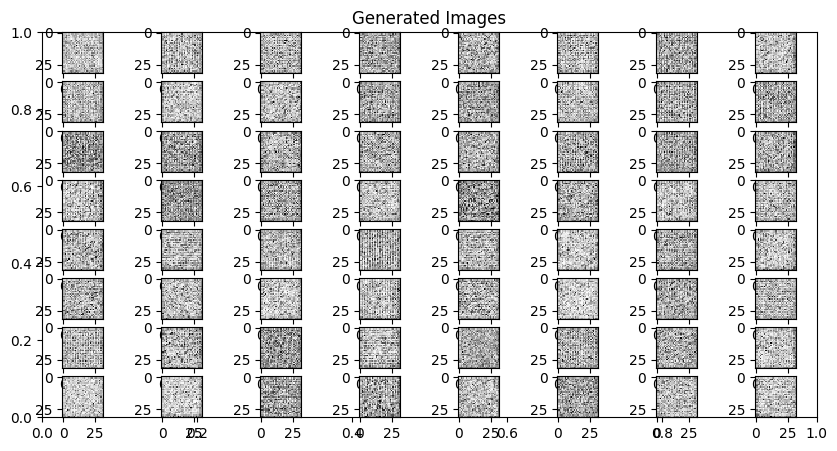

Batch No.: 501 / 938 : GLoss= 4.3084 DLoss= 0.0639


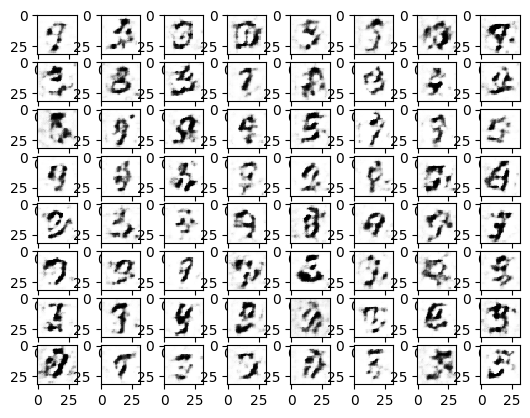

Epoch 2 / 5 :
Batch No.: 1 / 938 : GLoss= 4.9437 DLoss= 0.013


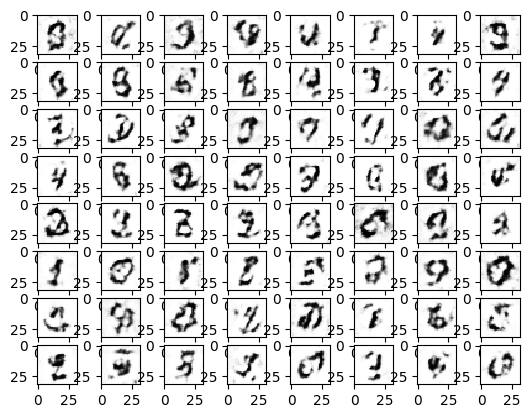

Batch No.: 501 / 938 : GLoss= 4.4724 DLoss= 0.0167


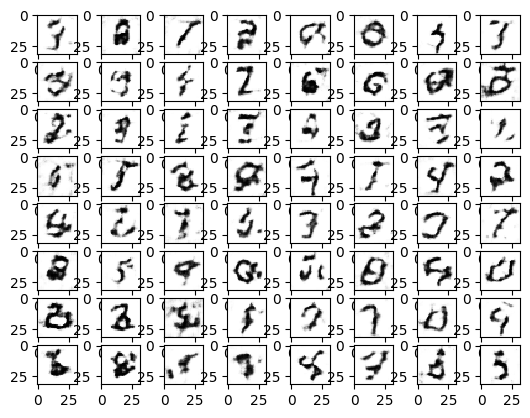

Epoch 3 / 5 :
Batch No.: 1 / 938 : GLoss= 4.2843 DLoss= 0.0199


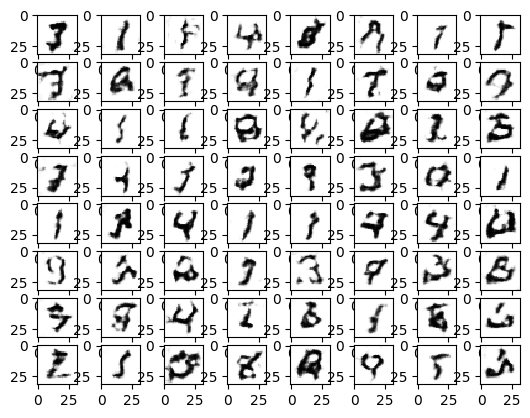

Batch No.: 501 / 938 : GLoss= 5.2362 DLoss= 0.0217


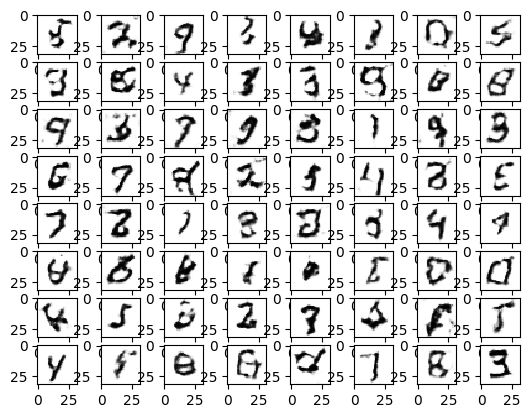

Epoch 4 / 5 :
Batch No.: 1 / 938 : GLoss= 4.8341 DLoss= 0.0075


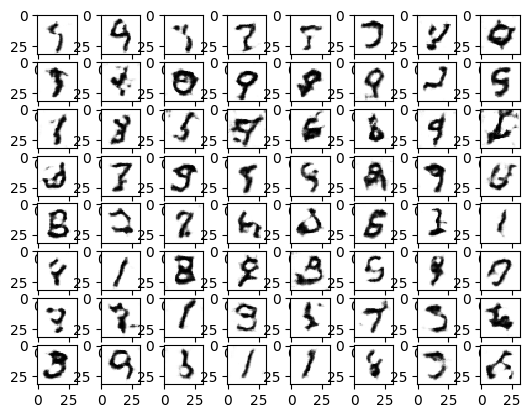

Batch No.: 501 / 938 : GLoss= 4.7625 DLoss= 0.0086


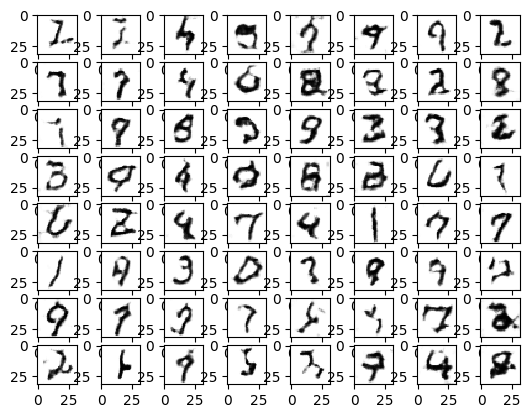

Epoch 5 / 5 :
Batch No.: 1 / 938 : GLoss= 6.3555 DLoss= 0.0027


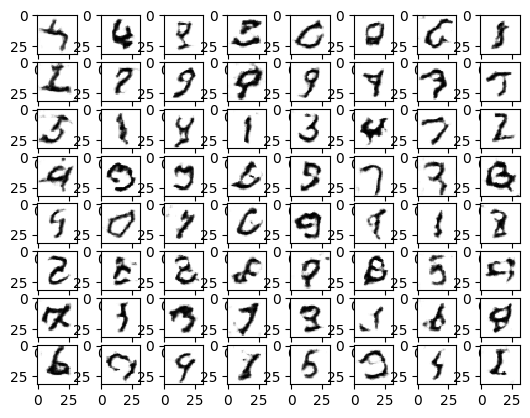

Batch No.: 501 / 938 : GLoss= 4.7075 DLoss= 0.0119


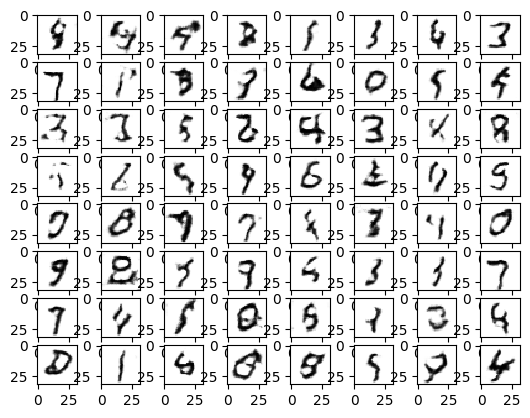

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Generated Images")
for e in range(n_epochs):
    print("Epoch",e+1,"/",n_epochs,":")
    train_one_epoch(plt)